In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

2.2.0+cu121


In [ ]:
# !pip install -q torch_geometric
# !pip install -q class_resolver
# !pip3 install pymatting


In [1]:
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import torch
# import util
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from numpy import asarray
import tifffile as tiff
import torch.nn as nn
import torch.nn.functional as nnFn
import torch_geometric.nn as pyg_nn
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
from torch.nn import CrossEntropyLoss
import random
from sklearn.cluster import KMeans

/home/snu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Load AD features
fa_feature_path = "/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy"
Histogram_feature_AD_FA_array = np.load(fa_feature_path, allow_pickle=True)

# Combine features and labels
X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_AD_FA_array])
y = np.hstack([
    np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
    np.ones(Histogram_feature_AD_FA_array.shape[0], dtype=np.int64)
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]
num_nodes, num_feats = X.shape
print(f"Features: {X.shape}, Labels: {y.shape}")

Features: (300, 180), Labels: (300,)


In [3]:
# F = np.concatenate((Histogram_feature_CN_FA_array, Histogram_feature_MCI_FA_array), axis=0)
# F = F.astype(np.float32)
# print("Combined Shape:", F.shape)
F = X
F = F.astype(np.float32)
print("Final Shape:", F.shape)
print("Data Type:", F.dtype)

Final Shape: (300, 180)
Data Type: float32


In [4]:
kmeans = KMeans(n_clusters=2, random_state=11, max_iter=5000)
kmeans.fit(F)

# Cluster probabilities
klabels_trans = kmeans.transform(F)
klabels_trans = klabels_trans / klabels_trans.sum(axis=1, keepdims=True)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
kS = torch.tensor(klabels_trans, dtype=torch.float32).to(device)

In [6]:
ground_truth_tensor = torch.tensor(y, dtype=torch.long).to(device)

In [7]:
criterion = CrossEntropyLoss()
loss = criterion(kS, ground_truth_tensor)
y_pred = torch.argmax(kS, dim=1).cpu().numpy()

In [8]:
acc_score = accuracy_score(y, y_pred)
acc_score_inverted = accuracy_score(y, 1 - y_pred)

if acc_score_inverted > acc_score:
    acc_score = acc_score_inverted
    y_pred = 1 - y_pred
    klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

y_pred_proba = klabels_trans[:, 1]

prec_score = precision_score(y, y_pred)
rec_score = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
log_loss_value = log_loss(y, y_pred_proba)

# Print metrics
print("Accuracy Score:", acc_score)
print("Precision Score:", prec_score)
print("Recall Score:", rec_score)
print("F1 Score:", f1)
print("Log Loss:", log_loss_value)

Accuracy Score: 0.7233333333333334
Precision Score: 0.795774647887324
Recall Score: 0.6766467065868264
F1 Score: 0.7313915857605178
Log Loss: 0.6329267940589133


In [9]:
print(y_pred_proba)

[0.58070135 0.5173665  0.6024661  0.42833897 0.63992417 0.41319692
 0.40443432 0.52194107 0.62788457 0.6054637  0.6190496  0.5484194
 0.5696041  0.51558375 0.6176691  0.61278    0.36077842 0.45798612
 0.60511065 0.62265915 0.4472961  0.6165393  0.59988374 0.5100882
 0.50809735 0.57097733 0.62535167 0.45453838 0.5961357  0.5679516
 0.47396523 0.60529846 0.48749137 0.4339891  0.5400738  0.6046543
 0.6050268  0.3965132  0.33363727 0.40369263 0.516602   0.48889285
 0.6390586  0.3995673  0.47126612 0.51765394 0.3468624  0.5515442
 0.44362676 0.4422733  0.5916453  0.603559   0.5070608  0.45696086
 0.6368534  0.3708288  0.38638628 0.43463573 0.3670015  0.41697344
 0.57749844 0.4155923  0.5132486  0.6026821  0.4205868  0.4231056
 0.37118647 0.5456966  0.40861076 0.4927506  0.3969468  0.47550297
 0.5097013  0.531328   0.5858435  0.37620237 0.44805217 0.4146688
 0.43271658 0.3806578  0.5359352  0.55302936 0.38918385 0.43754238
 0.4173982  0.37651342 0.39402163 0.4010827  0.44637883 0.37781817
 0

In [10]:
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score  # <-- added
)
from torch.nn import CrossEntropyLoss

fa_feature_path = "/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy"
Histogram_feature_CN_FA_array = np.load(fa_feature_path, allow_pickle=True)

fa_feature_path = "/home/snu/Downloads/Histogram_AD_FA_20bin_updated.npy"
Histogram_feature_AD_FA_array = np.load(fa_feature_path, allow_pickle=True)

X = np.vstack([Histogram_feature_CN_FA_array, Histogram_feature_AD_FA_array])
y = np.hstack([
    np.zeros(Histogram_feature_CN_FA_array.shape[0], dtype=np.int64),
    np.ones(Histogram_feature_AD_FA_array.shape[0], dtype=np.int64)
])

np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X    = X[perm]
y    = y[perm]

num_nodes, num_feats = X.shape
print(f"Features: {X.shape}, Labels: {y.shape}")

F         = X.astype(np.float32)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = CrossEntropyLoss()
num_runs  = 10

acc_scores  = []
prec_scores = []
rec_scores  = []
f1_scores   = []
log_losses  = []
ce_losses   = []
nmi_scores  = []   # <-- added

for run in range(num_runs):
    print(f"\n--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)
    torch.manual_seed(run)

    kmeans = KMeans(n_clusters=2, random_state=run, max_iter=5000)
    kmeans.fit(F)

    klabels_trans = kmeans.transform(F)
    klabels_trans = klabels_trans / klabels_trans.sum(axis=1, keepdims=True)

    kS                   = torch.tensor(klabels_trans, dtype=torch.float32).to(device)
    ground_truth_tensor  = torch.tensor(y, dtype=torch.long).to(device)
    ce_loss_value        = criterion(kS, ground_truth_tensor).item()

    y_pred    = torch.argmax(kS, dim=1).cpu().numpy()
    acc_score = accuracy_score(y, y_pred)

    acc_score_inverted = accuracy_score(y, 1 - y_pred)
    if acc_score_inverted > acc_score:
        acc_score             = acc_score_inverted
        y_pred                = 1 - y_pred
        klabels_trans[:, [0, 1]] = klabels_trans[:, [1, 0]]

    y_pred_proba = klabels_trans[:, 1]

    prec_score     = precision_score(y, y_pred, zero_division=0)
    rec_score      = recall_score(y, y_pred, zero_division=0)
    f1             = f1_score(y, y_pred, zero_division=0)
    log_loss_value = log_loss(y, y_pred_proba)

    # ── NMI: one value per run, final model only ──
    nmi = normalized_mutual_info_score(y, y_pred, average_method='arithmetic')

    acc_scores.append(acc_score)
    prec_scores.append(prec_score)
    rec_scores.append(rec_score)
    f1_scores.append(f1)
    log_losses.append(log_loss_value)
    ce_losses.append(ce_loss_value)
    nmi_scores.append(nmi)   # <-- added

    print(f"Run {run+1} | Acc: {acc_score:.4f} | Prec: {prec_score:.4f} | "
          f"Rec: {rec_score:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f} | "
          f"LogLoss: {log_loss_value:.4f} | CE Loss: {ce_loss_value:.4f}")

print("\n================ FINAL SUMMARY ================\n")
print(f"{'Metric':>15} | {'Mean':>10} ± {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f}  ± {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f}  ± {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f}  ± {np.std(f1_scores):.4f}")
print(f"{'NMI':>15} | {np.mean(nmi_scores):.4f}  ± {np.std(nmi_scores):.4f}")   # <-- added
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f}  ± {np.std(log_losses):.4f}")
print(f"{'CE Loss':>15} | {np.mean(ce_losses):.4f}  ± {np.std(ce_losses):.4f}")

Features: (223, 180), Labels: (223,)

--- Run 1/10 ---
Run 1 | Acc: 0.7713 | Prec: 0.7600 | Rec: 0.6333 | F1: 0.6909 | NMI: 0.2086 | LogLoss: 0.5973 | CE Loss: 0.7547

--- Run 2/10 ---
Run 2 | Acc: 0.7713 | Prec: 0.7468 | Rec: 0.6556 | F1: 0.6982 | NMI: 0.2079 | LogLoss: 0.5995 | CE Loss: 0.6425

--- Run 3/10 ---
Run 3 | Acc: 0.7713 | Prec: 0.7600 | Rec: 0.6333 | F1: 0.6909 | NMI: 0.2086 | LogLoss: 0.5973 | CE Loss: 0.7547

--- Run 4/10 ---
Run 4 | Acc: 0.7713 | Prec: 0.7468 | Rec: 0.6556 | F1: 0.6982 | NMI: 0.2079 | LogLoss: 0.5995 | CE Loss: 0.7532

--- Run 5/10 ---
Run 5 | Acc: 0.7713 | Prec: 0.7600 | Rec: 0.6333 | F1: 0.6909 | NMI: 0.2086 | LogLoss: 0.5973 | CE Loss: 0.7547

--- Run 6/10 ---
Run 6 | Acc: 0.7713 | Prec: 0.7468 | Rec: 0.6556 | F1: 0.6982 | NMI: 0.2079 | LogLoss: 0.5995 | CE Loss: 0.6425

--- Run 7/10 ---
Run 7 | Acc: 0.7713 | Prec: 0.7600 | Rec: 0.6333 | F1: 0.6909 | NMI: 0.2086 | LogLoss: 0.5973 | CE Loss: 0.7547

--- Run 8/10 ---
Run 8 | Acc: 0.7713 | Prec: 0.7468 

==== Running KMeans on PCA (2D) Features Across Multiple Runs ====

--- Run 1/10 ---
Run 1 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 2/10 ---
Run 2 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 3/10 ---
Run 3 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 4/10 ---
Run 4 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 5/10 ---
Run 5 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 6/10 ---
Run 6 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 7/10 ---
Run 7 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 8/10 ---
Run 8 | Acc: 0.7668 | Prec: 0.7500 | Rec: 0.6333 | F1: 0.6867 | NMI: 0.2002 | LogLoss: 0.5432
--- Run 9/10 ---
Run 9 | Acc: 0.7668 | Prec:

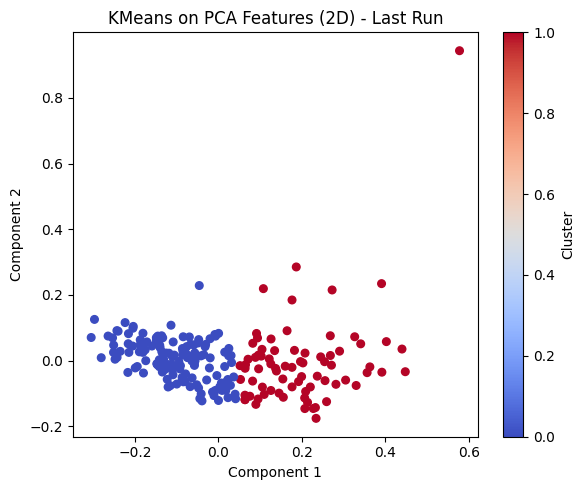

In [12]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, log_loss, normalized_mutual_info_score
)

# -------- PCA on INPUT FEATURES --------
pca = PCA(n_components=2)
Z   = pca.fit_transform(X)   # Z is now (N, 2)

num_runs = 10

acc_scores  = []
prec_scores = []
rec_scores  = []
f1_scores   = []
log_losses  = []
nmi_scores  = []

print("==== Running KMeans on PCA (2D) Features Across Multiple Runs ====\n")

for run in range(num_runs):
    print(f"--- Run {run+1}/{num_runs} ---")
    np.random.seed(run)

    # -------- KMEANS ON 2D PCA FEATURES --------
    kmeans_pca = KMeans(n_clusters=2, random_state=run, max_iter=5000, n_init=10)
    kmeans_pca.fit(Z)

    probs_pca = kmeans_pca.transform(Z)
    probs_pca = probs_pca / probs_pca.sum(axis=1, keepdims=True)

    y_pred_pca = np.argmax(probs_pca, axis=1)

    # Fix label flip
    acc     = accuracy_score(y, y_pred_pca)
    acc_inv = accuracy_score(y, 1 - y_pred_pca)
    if acc_inv > acc:
        y_pred_pca          = 1 - y_pred_pca
        probs_pca[:, [0,1]] = probs_pca[:, [1,0]]
        acc                 = acc_inv

    prec = precision_score(y, y_pred_pca, zero_division=0)
    rec  = recall_score(y, y_pred_pca,    zero_division=0)
    f1   = f1_score(y, y_pred_pca,        zero_division=0)
    ll   = log_loss(y, probs_pca[:, 1])
    nmi  = normalized_mutual_info_score(y, y_pred_pca, average_method='arithmetic')

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    log_losses.append(ll)
    nmi_scores.append(nmi)

    print(f"Run {run+1} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | NMI: {nmi:.4f} | LogLoss: {ll:.4f}")

print("\n================ FINAL SUMMARY (KMeans on PCA 2D) ================\n")
print(f"{'Metric':>15} | {'Mean':>10} \u00b1 {'Std':<10}")
print("-" * 50)
print(f"{'Accuracy':>15} | {np.mean(acc_scores):.4f}  \u00b1 {np.std(acc_scores):.4f}")
print(f"{'Precision':>15} | {np.mean(prec_scores):.4f} \u00b1 {np.std(prec_scores):.4f}")
print(f"{'Recall':>15} | {np.mean(rec_scores):.4f}  \u00b1 {np.std(rec_scores):.4f}")
print(f"{'F1 Score':>15} | {np.mean(f1_scores):.4f}  \u00b1 {np.std(f1_scores):.4f}")
print(f"{'NMI':>15} | {np.mean(nmi_scores):.4f}  \u00b1 {np.std(nmi_scores):.4f}")
print(f"{'Log Loss':>15} | {np.mean(log_losses):.4f}  \u00b1 {np.std(log_losses):.4f}")

# -------- PLOT (Displaying for the last run) --------
plt.figure(figsize=(6, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=y_pred_pca, cmap='coolwarm', s=30)
plt.title("KMeans on PCA Features (2D) - Last Run")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()